In [1]:
import re
import textwrap
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from plottable.cmap import normed_cmap
from plottable import Table, ColumnDefinition

In [2]:
# load scAtlasTb metrics output file
df_raw = pd.read_csv("/lustre/groups/ml01/workspace/arne.berg/AdultHeartAtlas/plots/qc/metrics.tsv",sep="\t")
df_raw = df_raw[["metric", "file_id", "integration_method", "score", "metric_type"]]
df_raw.sort_values(by="metric_type", inplace=True)

In [3]:
# dictionary mapping metric to its metric_type (batch_correction or bio conservation)
unique_pairs = df_raw[['metric', 'metric_type']].drop_duplicates()
D1 = dict(zip(unique_pairs['metric'], unique_pairs['metric_type']))
metric_groups = {
     'Bio conservation': [a for a in D1.keys() if D1[a]=='bio_conservation'],
     'Batch correction': [a for a in D1.keys() if D1[a]=='batch_correction'],
     'Overall': ['overall_mean']}

In [4]:
# pivot datadframe to have metrics as columns and methods as rows
df = df_raw.pivot_table(
    index='file_id', 
    columns='metric', 
    values='score',
    sort=False
).reset_index()
df.rename({"file_id":"Method"},axis=1,inplace=True)

In [5]:
# OPTIONAL: format methods names for better readability
def format_method(name):
    m = re.match(r"^([a-zA-Z]+)_(\d+|custom)_hvgs(?:_(no_celltype|celltype))?$", name)
    if not m:
        return name
    tool, n, ct = m.groups()
    tool = tool_name_map.get(tool.lower(), tool)
    inside = f"{n} hvgs"
    if ct == "celltype":
        inside += ", celltype"
    elif ct == "no_celltype":
        inside += ", no celltype"
    return f"{tool} ({inside})"

tool_name_map = {
    "drvi": "DRVI",
    "scvi": "scVI",
    "scanvi": "scANVI",
    "scpoli": "scPoli",
    "harmonypy": "Harmony",
}
df["Method"] = df["Method"].apply(format_method)

In [6]:
# OPTIONAL: rename cell typye metrics for better clarity
rename_dict = {
    "M's I:Final Level 1_harmonized": "M's I:Level 1",
    "M's I:Final Level 2_harmonized": "M's I:Level 2",
    "M's I:Final Level 3_harmonized": "M's I:Level 3",
    "M's I:Final Level 4_harmonized": "M's I:Level 4",
    "pcr:Final Level 3_harmonized": "PCR:Level 3"
}
df.rename(columns=rename_dict, inplace=True)

In [11]:
def plot_grouped_metrics_vertical(df, metric_groups, exclude_gene_sets=False, exclude_metrics=None, exclude_methods=None, group_cmaps=None,  show=True, save_path=None):
    """Plot grouped metrics vertically with methods as columns and metrics as rows."""

    plot_df = df.copy()

    if group_cmaps is None:
        group_cmaps = {
            'Batch correction': mpl.cm.Reds,
            'Bio conservation': mpl.cm.Blues,
            'Overall': mpl.cm.Purples
            }

    # Apply exclusion filters
    if exclude_metrics:
        plot_df.drop(columns=exclude_metrics, inplace=True, errors='ignore')
    if exclude_methods:
        plot_df.drop(columns=exclude_methods, inplace=True, errors='ignore')
    if exclude_gene_sets:
        gs_cols = [col for col in plot_df.columns if col.startswith("M's I gs:")]
        plot_df.drop(columns=gs_cols, inplace=True, errors='ignore')

    # reorder metric groups 
    metric_groups = {
        group_name: sorted([rename_dict.get(col, col) for col in columns], key=str.lower)
        for group_name, columns in metric_groups.items()
    }

    # reorder plot_df to match metric groups
    ordered_cols = ["Method"]
    for cols in metric_groups.values():
        ordered_cols.extend([col for col in cols if col in plot_df.columns])
    plot_df = plot_df.reindex(columns=ordered_cols)

    # calculate mean for each metric group
    for group_name, columns in metric_groups.items():
        existing_cols = [col for col in columns if col in plot_df.columns]
        if existing_cols:
            plot_df[f'{group_name}_mean'] = plot_df[existing_cols].mean(axis=1)

    if 'Batch correction_mean' in plot_df.columns and 'Bio conservation_mean' in plot_df.columns:
        plot_df['Overall_mean'] = plot_df[['Bio conservation_mean', 'Batch correction_mean']].mean(axis=1)
        plot_df = plot_df.sort_values('Overall_mean', ascending=False)
    
    for col in ['Total', 'Batch correction', 'Bio conservation']:
        if col in plot_df.columns:
            del plot_df[col]

    # Map columns back to its group
    row_to_group = {}
    metric_rows = []
    group_boundaries = []

    for group_name, columns in metric_groups.items():
        for col in columns:
            row_to_group[col] = group_name

    for group in metric_groups.keys():
        row_to_group[f'{group}_mean'] = group

    mean_priority = ['Overall', 'Bio conservation', 'Batch correction']
    mean_rows = [f'{group}_mean' for group in mean_priority if f'{group}_mean' in plot_df.columns]
    metric_rows.extend(mean_rows)
    group_boundaries.append(len(metric_rows) - 1)

    for group_name, columns in metric_groups.items():
        existing = [col for col in columns if col in plot_df.columns]
        metric_rows.extend(existing)
        if existing:
            group_boundaries.append(len(metric_rows) - 1)

    n_metric_rows = len(metric_rows)
    group_boundaries = sorted(set(b for b in group_boundaries if 0 <= b < n_metric_rows - 1))

    row_normmaps = {
        row: normed_cmap(
            plot_df[row],
            cmap=group_cmaps.get(row_to_group.get(row), mpl.cm.PRGn),
            num_stds=2.5
        )
        for row in metric_rows
    }

    # transpose the dataframe
    t_df = plot_df.set_index('Method')[metric_rows].T
    t_df.index.name = 'Metric'
    t_df = t_df.reset_index()

    method_order = list(plot_df['Method'])

    def make_method_cmap():
        """Return a colormap function that applies metric specific normalizations."""
        state = {"i": 0}
        def _cmap(val):
            row_label = metric_rows[state["i"]]
            state["i"] += 1
            return row_normmaps[row_label](val)
        return _cmap

    def format_metric_label(name, width=15):
        """Splitting labels over multiple lines and replacing underscores with spaces for better readability."""
        name = name.upper().replace('_', ' ')
        if ':' in name:
            name = name.replace(':', ':\n', 1)
        return "\n".join(
            line for part in name.split("\n")
            for line in textwrap.wrap(part, width=width) or [""]
        )

    column_definitions = [
        ColumnDefinition(
            "Metric",
            width=3.5,
            textprops={"ha": "center"},
            border="right",
            formatter=format_metric_label,
        )
    ]

    for method in method_order:
        if method in t_df.columns:
            column_definitions.append(
                ColumnDefinition(
                    method,
                    title=method.replace('_', ' '),
                    width=1,
                    textprops={
                        "ha": "center",
                        "bbox": {"boxstyle": "circle", "pad": 0.05},
                    },
                    cmap=make_method_cmap(),  # fresh counter per column
                    formatter="{:.3f}",
                    border="left"
                    )
            )

    t_df = t_df.reindex(columns=["Metric"] + [m for m in method_order if m in t_df.columns])

    with mpl.rc_context({"svg.fonttype": "none"}):
        fig_width = 3.8 + 0.38 * (len(t_df.columns) - 1)
        fig_height = len(t_df) * 0.85 + 1.5
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        tab = Table(
            t_df,
            cell_kw={"linewidth": 0, "edgecolor": "k"},
            column_definitions=column_definitions,
            ax=ax,
            row_dividers=True,
            footer_divider=True,
            textprops={"fontsize": 9, "ha": "center"},
            row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            index_col="Metric",
        ).autoset_fontcolors(colnames=t_df.columns)

        for cell in tab.col_label_row.cells[1:]:
            cell.text.set_rotation(90)
            cell.text.set_ha("left")
            cell.text.set_fontsize(11)
            cell.text.set_fontweight("bold")
            cell.text.set_va("bottom")

        x0, x1 = list(tab.rows.values())[0].get_xrange()
        for boundary_idx in group_boundaries:
            y = boundary_idx + 1
            ax.plot([x0, x1], [y, y], color="black", linewidth=1.5, linestyle="-", zorder=5)
        
        y0, y1 = ax.get_ylim()
        x_boundary = column_definitions[0].width
        ax.plot([x_boundary, x_boundary], [y0, y1], color="black", linewidth=1.5, linestyle="-", zorder=6)

    if show:
        plt.tight_layout(pad=1.2)
        plt.show()

    if save_path:
        fig.savefig(save_path, facecolor=ax.get_facecolor(), dpi=300, bbox_inches='tight')

    return tab, t_df

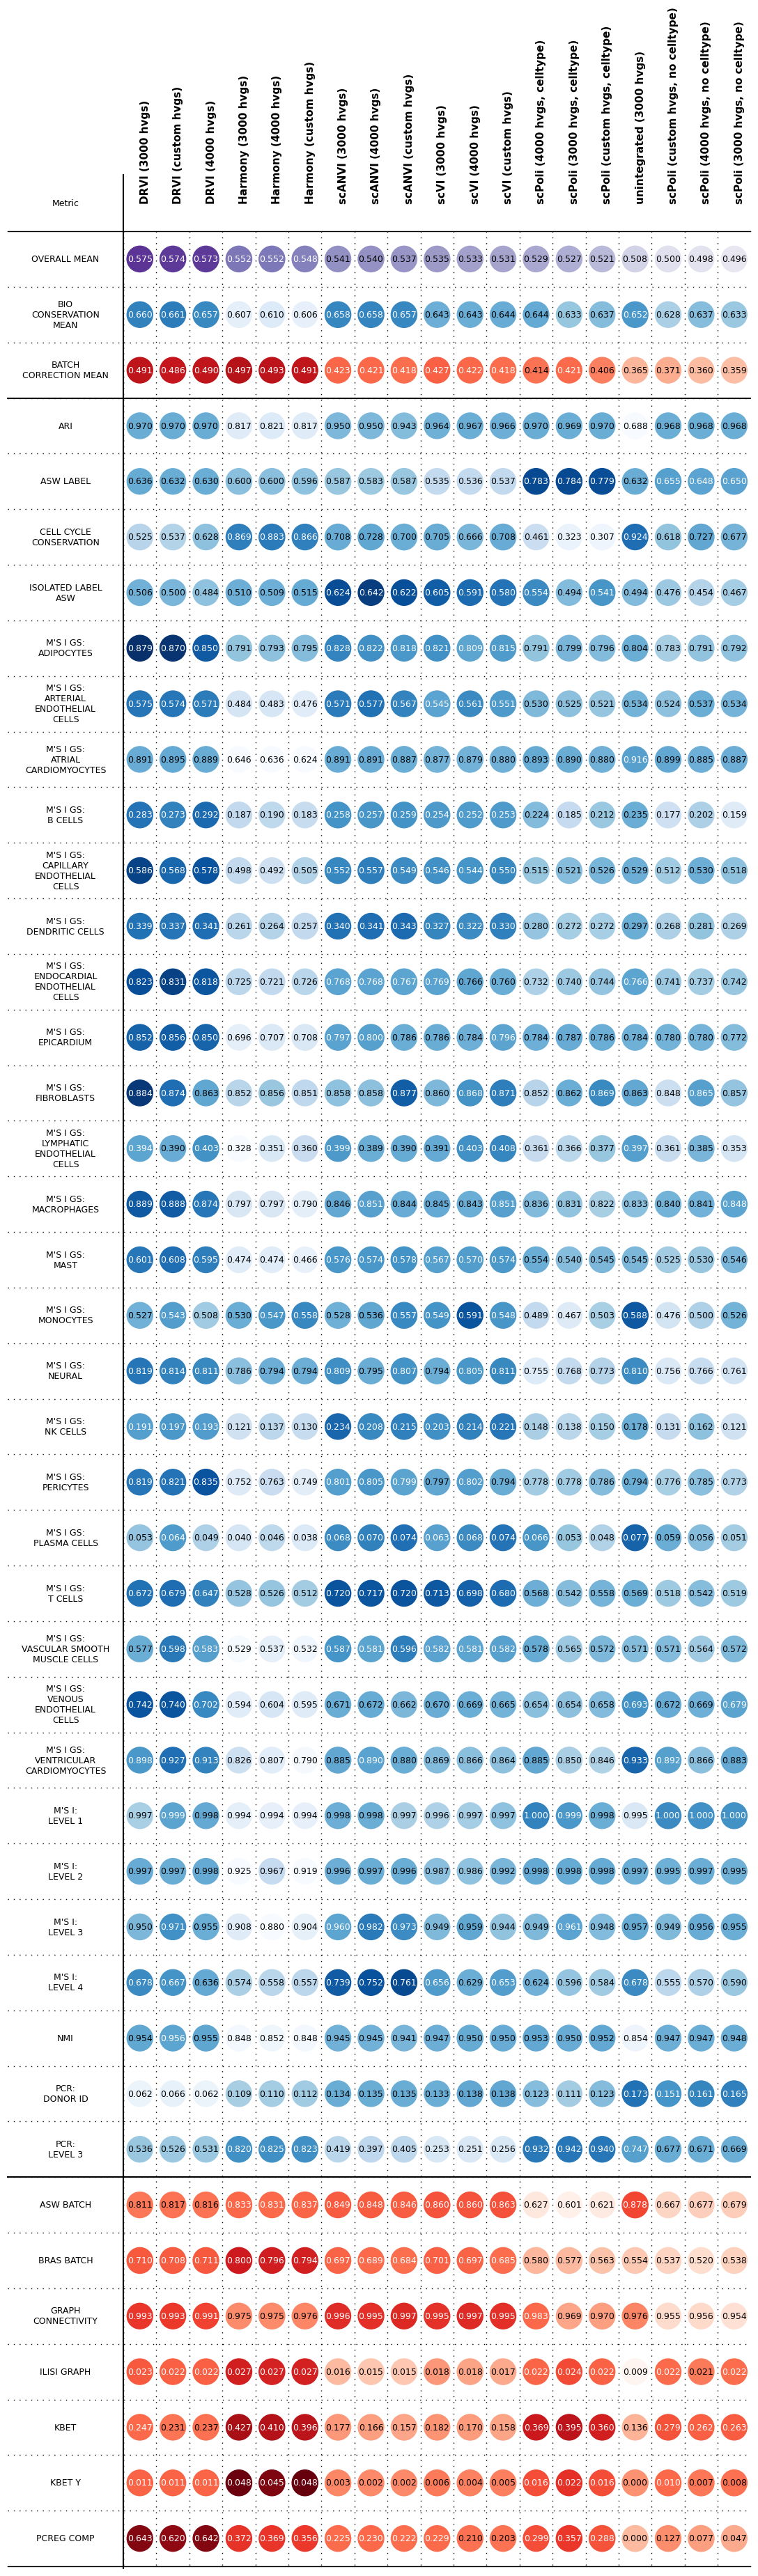

In [12]:
tab, plot_df = plot_grouped_metrics_vertical(
    df,
    metric_groups,
    exclude_metrics=["morans_i_random", "cLISI graph", "pcr_random"],
    exclude_methods=["unintegrated (3000 hvgs)"],
    save_path='/lustre/groups/ml01/projects/2025_heart_atlas_integration_iterations_lennard.halle_arne.vandenberg/plots/metrics/final_benchmark_metrics_combined_with_genesets_T_3digits.pdf')